# 01 — Topic landscape

**The question**: at the finest granularity the model offers — 373 individual topics — what
actually differs between books readers rate highly and books they rate poorly?

This is deliberately the least theory-laden chapter. No composites, no hypotheses, no
taxonomy grouping. Just: take each topic in turn, compare its share of sentences between
the high-rated and low-rated thirds of the corpus, and see what survives.

Starting here matters. If the theory axes in later chapters show effects that no individual
topic shows, the axes are manufacturing signal. And if a topic-level effect is strong but
vanishes once grouped into a taxonomy category, the grouping is what destroyed it. This
chapter is the reference point for both.

**How to read the results.** With about 5,000 books in each tier, statistical significance
is nearly free — the interesting question is never "is it significant" but "is it big enough
to notice". So the reporting order throughout is: effect size first, confidence interval
second, p-value as a footnote.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
project_root = cwd
for _ in range(6):
    if (project_root / "configs").is_dir() and (project_root / "src").is_dir():
        break
    project_root = project_root.parent
else:
    raise RuntimeError("Could not find project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.stage10_correlation_analysis.analysis import compositional as comp
from src.stage10_correlation_analysis.analysis import effects as eff
from src.stage10_correlation_analysis.analysis import notebook_helpers as nbh
from src.stage10_correlation_analysis.analysis import tests as tst

ctx = nbh.setup("01_topic_landscape")
cfg = ctx.cfg
TIERS = cfg.tier_order
TIER_COL = cfg.tier_column
PALETTE = nbh.tier_palette(cfg)
HIGH, LOW = cfg.section("tiers", "headline_contrast")

frame = nbh.load_analysis_frame(cfg).reset_index()
topic_lookup = nbh.load_topic_lookup(cfg)
TOPIC_COLS = nbh.columns_with_prefix(frame, "topic_")
LABELS = nbh.topic_label_map(topic_lookup)

print(f"\n{len(frame):,} books, {len(TOPIC_COLS)} topics.")
print(f"Headline contrast: {HIGH} (n={int((frame[TIER_COL] == HIGH).sum()):,}) "
      f"vs {LOW} (n={int((frame[TIER_COL] == LOW).sum()):,}).")

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage10/final_analysis.yaml
Run          : v4_l12_granular_final_call49
Model        : BERTopic call_49 — MiniLM-L12, 374 topics (348 mapped + outliers)
Outputs      : results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape



16,000 books, 373 topics.
Headline contrast: high_rate (n=5,086) vs low_rate (n=5,390).


## 1. Which topics are even eligible?

A topic that barely appears cannot support a comparison. Two gates:

- **prevalence** — present in at least 5% of books
- **mass** — at least 0.05% of sentences on average

As notebook 00 showed, prevalence barely bites at this granularity: a book has ~6,800
sentences over 373 topics, so nearly every topic appears somewhere in nearly every book.
The mass gate is what does the filtering, and even it removes only a handful. The real
filter is the effect-size gate further down, and that is the honest story of this chapter.

In [2]:
screen = comp.screen_columns(
    frame[TOPIC_COLS],
    min_prevalence=float(cfg.section("screening", "min_prevalence_books")),
    min_mean_share=float(cfg.section("screening", "min_mean_share")),
)
eligible = screen.index[screen["passes_screen"]].tolist()

print(f"eligible topics: {len(eligible)} of {len(TOPIC_COLS)}")
excluded = screen[~screen["passes_screen"]]
if len(excluded):
    show = excluded.copy()
    show["label"] = show.index.map(LABELS)
    print("\nExcluded, and why:")
    display(show[["label", "prevalence", "mean_share", "passes_prevalence", "passes_mean_share"]])

eligible topics: 369 of 373

Excluded, and why:


,label,prevalence,mean_share,passes_prevalence,passes_mean_share
topic_345,Older Man Trading Shelter For Sex,0.2923,0.0005,True,False
topic_365,Frantic Longing After Weeks Apart,0.2363,0.0004,True,False
topic_303,Confessing Long-Hidden Secrets,0.2243,0.0004,True,False
topic_362,Keeping Someone Watched and Close,0.1195,0.0003,True,False


## 2. Do the three tiers differ at all? (omnibus)

Before comparing pairs of tiers, ask the blunt question: for each topic, is there *any*
difference across the three rating tiers? A Kruskal–Wallis test answers that on ranks, so
it makes no assumption about the shape of the distribution — which matters, because topic
shares are bounded below at zero and have a long right tail.

Alongside it, **epsilon-squared** gives the share of rank variance explained by tier. One
caution about its scale: with three equal tiers, even perfect separation only reaches about
8/9, because rank variance *within* a tier never goes away. So compare these numbers to
each other, not to 1.

P-values are corrected with Benjamini–Hochberg across all eligible topics — false discovery
rate, not familywise error, because 373 tests would make Bonferroni-style control
pointlessly conservative. Topics are one of five separately corrected families in this
analysis (topics, leaves, main groups, axes, hypotheses); pooling them would let the large
topic family consume the small hypothesis family's alpha budget.

In [3]:
omnibus = tst.kruskal_wallis(frame, eligible, TIER_COL, TIERS)
omnibus = tst.adjust_within_family(
    omnibus, "p_value", method=cfg.section("inference", "fdr_method"),
    alpha=float(cfg.section("inference", "fdr_alpha")),
)
omnibus["label"] = omnibus["feature"].map(LABELS)

alpha = float(cfg.section("inference", "fdr_alpha"))
print(f"Topics with any tier difference at BH-FDR q < {alpha}: "
      f"{int(omnibus['q_value_significant'].sum())} of {len(omnibus)}")
print(f"Largest epsilon-squared: {omnibus['epsilon_squared'].max():.4f} "
      f"({omnibus.iloc[0]['label']})")
print(f"Median epsilon-squared:  {omnibus['epsilon_squared'].median():.4f}\n")
print("The gap between those two lines is the point: a great many topics differ detectably,")
print("and almost none differ substantially. Both facts are real and both need reporting.")

display(omnibus.head(15)[["feature", "label", "epsilon_squared", "kw_statistic",
                          "p_value", "q_value"]])

Topics with any tier difference at BH-FDR q < 0.05: 282 of 369
Largest epsilon-squared: 0.0254 (Promising to Find Her)
Median epsilon-squared:  0.0014

The gap between those two lines is the point: a great many topics differ detectably,
and almost none differ substantially. Both facts are real and both need reporting.


,feature,label,epsilon_squared,kw_statistic,p_value,q_value
0,topic_100,Promising to Find Her,0.0254,405.6560,0.0000,0.0000
1,topic_309,NaN,0.0146,234.8772,0.0000,0.0000
2,topic_91,Arguing Over Guns and Weapons,0.0139,222.3921,0.0000,0.0000
3,topic_78,Swearing War Before He Takes Her,0.0137,219.4435,0.0000,0.0000
4,topic_87,Threatening Death As A Warning,0.0133,212.1412,0.0000,0.0000
5,topic_119,Offering to Keep Her Safe,0.0126,202.2188,0.0000,0.0000
6,topic_81,Mentioning A Brother,0.0126,202.0648,0.0000,0.0000
7,topic_238,Relaying A Message For Her,0.0113,180.1029,0.0000,0.0000
8,topic_55,Worrying About An Unplanned Pregnancy,0.0111,178.3166,0.0000,0.0000
9,topic_310,NaN,0.0111,178.0110,0.0000,0.0000


## 3. The headline contrast: high-rated versus low-rated

Now the specific comparison the rest of the analysis leans on. **Cliff's delta** is the
probability that a randomly chosen high-rated book devotes more of its sentences to a topic
than a randomly chosen low-rated book, minus the reverse. It runs from −1 to +1, needs no
distributional assumptions, and reads directly as "how often does one exceed the other".

Conventional thresholds (Romano et al. 2006): 0.11 small, 0.28 medium, 0.43 large.

Each delta gets a bootstrap confidence interval, resampling books within tier. The interval
is the thing to read: an interval that comfortably excludes zero and sits above 0.11 is a
result, and one that straddles 0.11 is a hint at best. (Author-level clustering enters in
notebook 08, where the same intervals are recomputed by resampling whole authors.)

In [4]:
delta_table = eff.two_group_effects(
    frame, eligible, TIER_COL, HIGH, LOW,
    n_replicates=int(cfg.section("inference", "screening_ci_replicates")),
    ci_level=float(cfg.section("inference", "bootstrap", "ci_level")),
    seed=int(cfg.section("inference", "bootstrap", "seed")),
)
delta_table = delta_table.merge(
    omnibus[["feature", "p_value", "q_value", "epsilon_squared"]], on="feature", how="left",
)
delta_table["label"] = delta_table["feature"].map(LABELS)
delta_table["topic_id"] = delta_table["feature"].str.removeprefix("topic_").astype(int)
delta_table = delta_table.merge(
    topic_lookup[["topic_id", "taxonomy_main_id", "taxonomy_main_name", "taxonomy_main_group",
                  "taxonomy_confidence", "taxonomy_evidence_quality", "radway_phase_name"]],
    on="topic_id", how="left",
)

gates = cfg.section("screening", "effect_gates")
counts = {
    name: int((delta_table["cliffs_delta"].abs() >= threshold).sum())
    for name, threshold in gates.items()
}
print("Topics by effect-size band (absolute Cliff's delta):")
for name, threshold in gates.items():
    print(f"  >= {threshold:.2f} ({name.split('_')[-1]:<6}): {counts[name]:>3}")
print(f"\nBootstrap CI excludes zero: {int(delta_table['ci_excludes_zero'].sum())} of {len(delta_table)}")
print("\nThat contrast is the chapter in one line. Nearly every topic differs 'significantly';")
print("only a few dozen differ by enough that a reader would ever notice.")

Topics by effect-size band (absolute Cliff's delta):
  >= 0.11 (small ):  38
  >= 0.28 (medium):   0
  >= 0.43 (large ):   0

Bootstrap CI excludes zero: 284 of 369

That contrast is the chapter in one line. Nearly every topic differs 'significantly';
only a few dozen differ by enough that a reader would ever notice.


## 4. The screening funnel

Rather than announce a final count of "findings", the funnel shows how many topics survive
each requirement in turn. It makes visible which gate is actually doing the work — and here
the statistical gate is nearly free while the effect-size gate removes almost everything.

,stage,n
0,all features tested,369
1,present in enough books and carries enough mass,369
2,survives BH-FDR at alpha=0.05,282
3,|Cliff's delta| >= 0.11,38
4,bootstrap CI excludes zero,38


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape/tables/screening_funnel.csv  (5 rows)

38 topics pass every gate.


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape/figures/screening_funnel.png


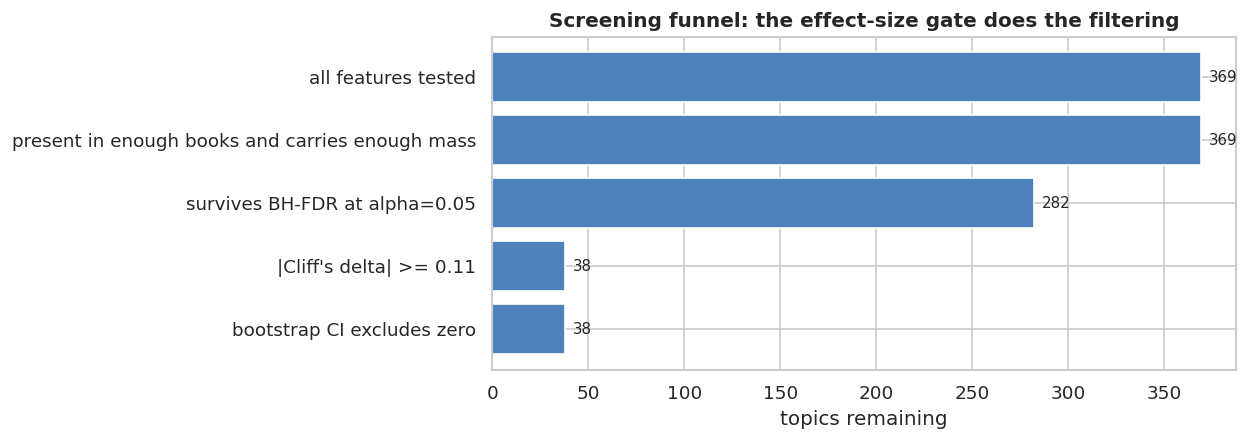

In [5]:
funnel, annotated = tst.screening_funnel(
    screen, delta_table,
    min_abs_delta=float(cfg.section("screening", "headline_gate", "min_abs_cliffs_delta")),
    require_ci_excludes_zero=bool(cfg.section("screening", "headline_gate", "require_ci_excludes_zero")),
    alpha=alpha,
)
display(funnel)
ctx.save_table(funnel, "screening_funnel")

survivors = annotated[annotated["passes_all"]].copy()
survivors = survivors.sort_values("cliffs_delta", key=lambda s: s.abs(), ascending=False)
print(f"\n{len(survivors)} topics pass every gate.")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(funnel["stage"][::-1], funnel["n"][::-1], color="#4f81bd")
for y, (stage, n) in enumerate(zip(funnel["stage"][::-1], funnel["n"][::-1])):
    ax.text(n + 4, y, f"{n}", va="center", fontsize=9)
ax.set_xlabel("topics remaining")
ax.set_title("Screening funnel: the effect-size gate does the filtering")
ctx.save_figure(fig, "screening_funnel")
plt.show()

## 5. Leaderboards: what high-rated books do more of, and less of

The two tables below are the substantive result of this chapter. `hodges_lehmann_shift` is
the typical difference in share between the tiers, expressed in percentage points of a
book's sentences, so it says how much and not only how reliably.

In [6]:
report_cols = ["label", "taxonomy_main_id", "taxonomy_main_name", "cliffs_delta",
               "ci_low", "ci_high", "magnitude", "mean_a", "mean_b",
               "hodges_lehmann_shift", "q_value"]


def as_percentage_points(table: pd.DataFrame) -> pd.DataFrame:
    out = table[report_cols].copy()
    out = out.rename(columns={"mean_a": f"mean_{HIGH}_%", "mean_b": f"mean_{LOW}_%",
                              "hodges_lehmann_shift": "typical_shift_pp"})
    for col in [f"mean_{HIGH}_%", f"mean_{LOW}_%", "typical_shift_pp"]:
        out[col] = out[col] * 100.0
    return out.round(4).reset_index(drop=True)


more_in_high = survivors[survivors["cliffs_delta"] > 0]
more_in_low = survivors[survivors["cliffs_delta"] < 0]

print(f"More prominent in HIGH-rated books ({len(more_in_high)} topics pass all gates):")
display(as_percentage_points(more_in_high.head(20)))

print(f"\nMore prominent in LOW-rated books ({len(more_in_low)} topics pass all gates):")
display(as_percentage_points(more_in_low.head(20)))

ctx.save_table(as_percentage_points(more_in_high), "leaderboard_more_in_high")
ctx.save_table(as_percentage_points(more_in_low), "leaderboard_more_in_low")
ctx.save_table(delta_table.sort_values("cliffs_delta", key=lambda s: s.abs(), ascending=False),
               "topic_tier_effects_full")

More prominent in HIGH-rated books (33 topics pass all gates):


,label,taxonomy_main_id,taxonomy_main_name,cliffs_delta,ci_low,ci_high,magnitude,mean_high_rate_%,mean_low_rate_%,typical_shift_pp,q_value
0,Promising to Find Her,9.2,"Promise, Vow & Future-Tense Speech Acts",0.2251,0.2034,0.2449,small,0.7982,0.6187,0.1533,0.0000
1,Arguing Over Guns and Weapons,7.2,"Violence, Threats & Non-Sexual Coercion",0.1659,0.1455,0.1879,small,0.2221,0.1674,0.0286,0.0000
2,Swearing War Before He Takes Her,7.2,"Violence, Threats & Non-Sexual Coercion",0.1650,0.1432,0.1861,small,0.2621,0.2091,0.0360,0.0000
3,NaN,NaN,NaN,0.1632,0.1406,0.1840,small,0.0899,0.0704,0.0155,0.0000
4,Threatening Death As A Warning,7.2,"Violence, Threats & Non-Sexual Coercion",0.1620,0.1419,0.1833,small,0.4067,0.3188,0.0565,0.0000
5,Offering to Keep Her Safe,4.6,"Emotional Safety, Reassurance & Caretaking",0.1598,0.1390,0.1812,small,0.3166,0.2617,0.0458,0.0000
6,Mentioning A Brother,5.1,"Family, Kinship & Parenthood",0.1563,0.1354,0.1772,small,0.2388,0.1921,0.0342,0.0000
7,NaN,NaN,NaN,0.1505,0.1264,0.1731,small,0.1600,0.1409,0.0199,0.0000
8,Relaying A Message For Her,9.2,"Promise, Vow & Future-Tense Speech Acts",0.1482,0.1249,0.1695,small,0.4233,0.3482,0.0563,0.0000
9,Told to Keep Up Strength,4.6,"Emotional Safety, Reassurance & Caretaking",0.1450,0.1218,0.1660,small,0.1749,0.1450,0.0228,0.0000



More prominent in LOW-rated books (5 topics pass all gates):


,label,taxonomy_main_id,taxonomy_main_name,cliffs_delta,ci_low,ci_high,magnitude,mean_high_rate_%,mean_low_rate_%,typical_shift_pp,q_value
0,Resenting Someone More Attractive,1.6,Character Appearance & Self-Presentation,-0.1453,-0.1666,-0.1238,small,0.4018,0.4683,-0.0531,0.0000
1,Lingering Farewell Kiss,2.2,Kissing & Non-Explicit Affection,-0.1313,-0.1534,-0.1101,small,0.2212,0.2687,-0.0338,0.0000
2,Stepping Out of Panties and Jeans,2.1,Attraction & Sexual Tension,-0.1296,-0.1491,-0.1056,small,0.3392,0.4135,-0.0507,0.0000
3,NaN,NaN,NaN,-0.1167,-0.1382,-0.0949,small,0.4799,0.5777,-0.0464,0.0000
4,Blush Creeping Up Her Cheeks,1.7,Facial Expression & Non-Sexual Nonverbal Cues,-0.1130,-0.1322,-0.0915,small,0.0919,0.1093,-0.0129,0.0000


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape/tables/leaderboard_more_in_high.csv  (33 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape/tables/leaderboard_more_in_low.csv  (5 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape/tables/topic_tier_effects_full.csv  (369 rows)


PosixPath('/home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape/tables/topic_tier_effects_full.csv')

  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape/figures/top_topic_effects.png


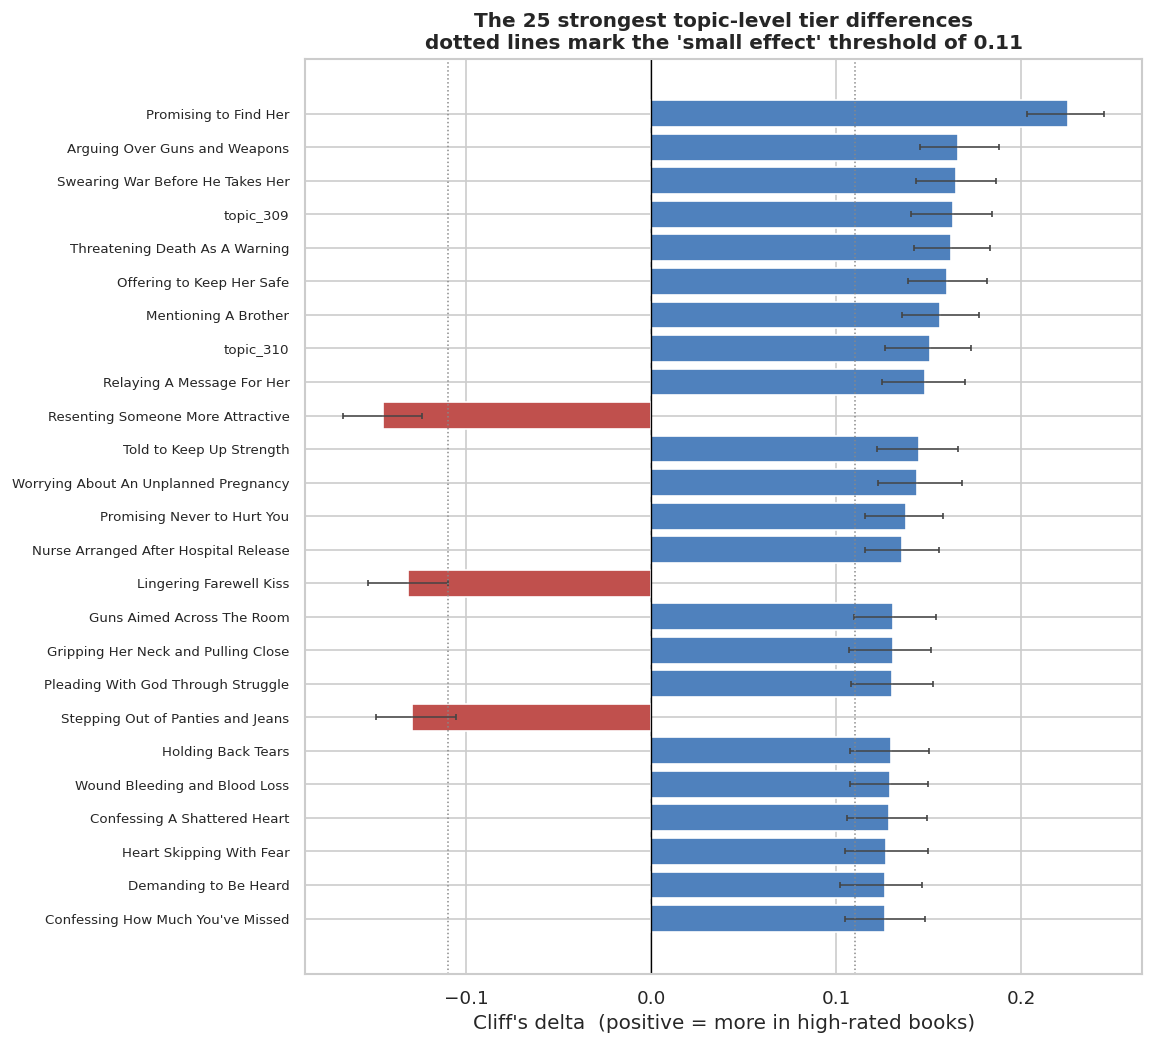

In [7]:
top_n = int(cfg.section("plotting", "max_bars"))
plot_data = survivors.reindex(
    survivors["cliffs_delta"].abs().sort_values(ascending=False).index
).head(top_n).copy()
plot_data["display"] = plot_data["label"].fillna(plot_data["feature"]).str.slice(0, 46)

fig, ax = plt.subplots(figsize=(9, 0.34 * len(plot_data) + 1.4))
colours = [PALETTE[HIGH] if d > 0 else PALETTE[LOW] for d in plot_data["cliffs_delta"]]
y = np.arange(len(plot_data))[::-1]
ax.barh(y, plot_data["cliffs_delta"], color=colours)
ax.errorbar(
    plot_data["cliffs_delta"], y,
    xerr=[plot_data["cliffs_delta"] - plot_data["ci_low"],
          plot_data["ci_high"] - plot_data["cliffs_delta"]],
    fmt="none", ecolor="#444444", elinewidth=0.9, capsize=2,
)
ax.set_yticks(y)
ax.set_yticklabels(plot_data["display"], fontsize=8)
ax.axvline(0, color="black", lw=0.8)
for gate_value in (gates["cliffs_delta_small"], -gates["cliffs_delta_small"]):
    ax.axvline(gate_value, color="#888888", ls=":", lw=0.9)
ax.set_xlabel("Cliff's delta  (positive = more in high-rated books)")
ax.set_title(f"The {len(plot_data)} strongest topic-level tier differences\n"
             "dotted lines mark the 'small effect' threshold of 0.11")
ctx.save_figure(fig, "top_topic_effects")
plt.show()

## 6. Effect versus prominence

A useful sanity check: are the discriminating topics the big ones or the small ones? If all
the effects sat on tiny topics, the story would be about marginal detail rather than about
what these books are mostly made of.

  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape/figures/effect_vs_prominence.png


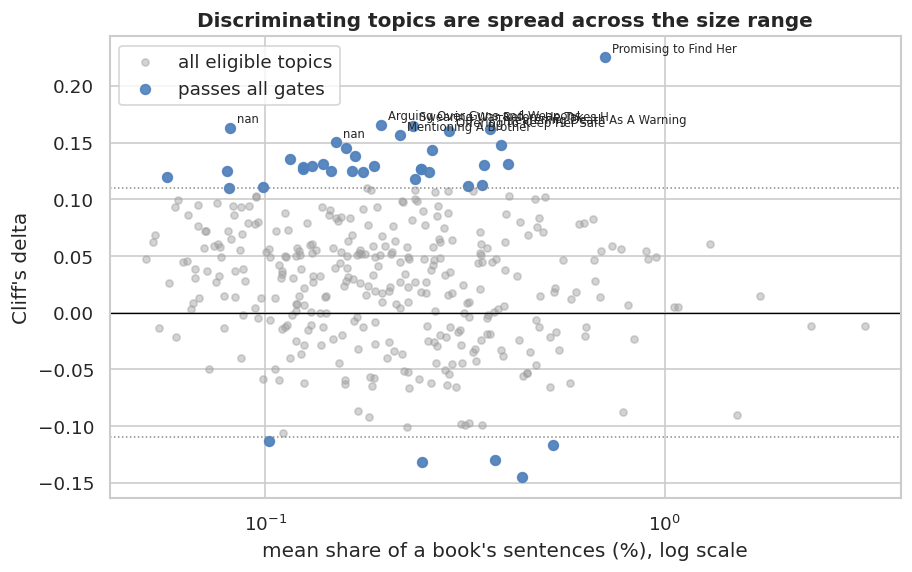

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.scatter(annotated["mean_share"] * 100, annotated["cliffs_delta"],
           s=18, alpha=0.45, color="#9e9e9e", label="all eligible topics")
ax.scatter(survivors["mean_share"] * 100, survivors["cliffs_delta"],
           s=34, alpha=0.9, color="#4f81bd", label="passes all gates")
ax.axhline(0, color="black", lw=0.8)
for gate_value in (gates["cliffs_delta_small"], -gates["cliffs_delta_small"]):
    ax.axhline(gate_value, color="#888888", ls=":", lw=0.9)
ax.set_xscale("log")
ax.set_xlabel("mean share of a book's sentences (%), log scale")
ax.set_ylabel("Cliff's delta")
ax.set_title("Discriminating topics are spread across the size range")
ax.legend()

for _, row in survivors.head(8).iterrows():
    ax.annotate(str(row["label"])[:30], (row["mean_share"] * 100, row["cliffs_delta"]),
                fontsize=7, xytext=(4, 3), textcoords="offset points")
ctx.save_figure(fig, "effect_vs_prominence")
plt.show()

## 7. Is the difference a gradient or a cliff?

"High-rated books do more of X" could mean two quite different things: X rises steadily
from low to mid to high, or X is flat across low and mid and then jumps. A steady gradient
is the stronger and more interpretable claim, so it is worth separating.

Spearman's rho against the tier index (0, 1, 2) measures monotone trend. A topic with a
large Cliff's delta *and* a monotone gradient is the most trustworthy kind of result here.

In [9]:
trend = tst.compare_tier_trend(frame, eligible, TIER_COL, TIERS)
trend["label"] = trend["feature"].map(LABELS)

combined = survivors[["feature", "label", "cliffs_delta", "magnitude"]].merge(
    trend[["feature", "spearman_rho", "direction"]], on="feature", how="left",
)
combined["monotone_and_consistent"] = (
    np.sign(combined["spearman_rho"]) == np.sign(combined["cliffs_delta"])
) & (combined["spearman_rho"].abs() >= 0.05)

n_mono = int(combined["monotone_and_consistent"].sum())
print(f"{n_mono} of {len(combined)} surviving topics show a monotone gradient across all "
      f"three tiers\nin the same direction as the high-vs-low contrast.")
display(combined.sort_values("spearman_rho", key=lambda s: s.abs(), ascending=False).head(15))
ctx.save_table(combined, "surviving_topics_trend")

38 of 38 surviving topics show a monotone gradient across all three tiers
in the same direction as the high-vs-low contrast.


,feature,label,cliffs_delta,magnitude,spearman_rho,direction,monotone_and_consistent
0,topic_100,Promising to Find Her,0.2251,small,0.1583,rises with rating,True
1,topic_91,Arguing Over Guns and Weapons,0.1659,small,0.1170,rises with rating,True
2,topic_78,Swearing War Before He Takes Her,0.1650,small,0.1167,rises with rating,True
3,topic_309,NaN,0.1632,small,0.1157,rises with rating,True
4,topic_87,Threatening Death As A Warning,0.1620,small,0.1143,rises with rating,True
5,topic_119,Offering to Keep Her Safe,0.1598,small,0.1124,rises with rating,True
6,topic_81,Mentioning A Brother,0.1563,small,0.1102,rises with rating,True
7,topic_310,NaN,0.1505,small,0.1055,rises with rating,True
8,topic_238,Relaying A Message For Her,0.1482,small,0.1043,rises with rating,True
10,topic_372,Told to Keep Up Strength,0.1450,small,0.1020,rises with rating,True


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape/tables/surviving_topics_trend.csv  (38 rows)


PosixPath('/home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape/tables/surviving_topics_trend.csv')

  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape/figures/tier_gradients.png


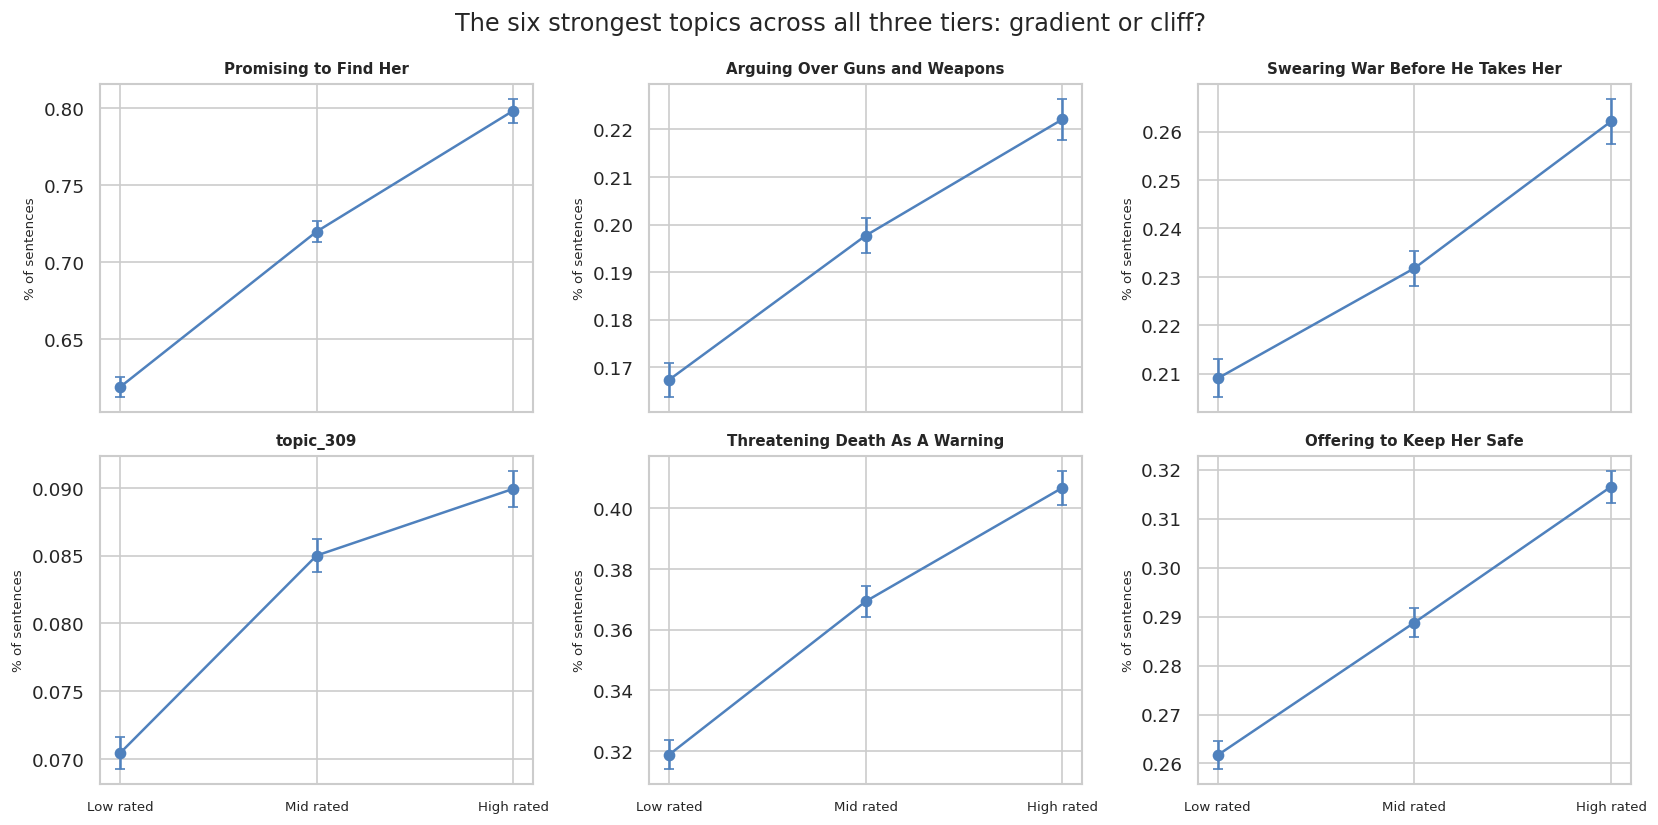

In [10]:
panel = survivors.head(6)["feature"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
for ax, col in zip(axes.ravel(), panel):
    means = frame.groupby(TIER_COL, observed=True)[col].mean().reindex(TIERS) * 100
    sems = (frame.groupby(TIER_COL, observed=True)[col].sem().reindex(TIERS) * 100)
    ax.errorbar(range(len(TIERS)), means.to_numpy(), yerr=sems.to_numpy(),
                marker="o", color="#4f81bd", capsize=3)
    ax.set_xticks(range(len(TIERS)))
    ax.set_xticklabels([cfg.section("tiers", "labels")[t] for t in TIERS], fontsize=8)
    ax.set_title(str(LABELS.get(col, col))[:40], fontsize=9)
    ax.set_ylabel("% of sentences", fontsize=8)
fig.suptitle("The six strongest topics across all three tiers: gradient or cliff?")
fig.tight_layout()
ctx.save_figure(fig, "tier_gradients")
plt.show()

## 8. Are the tier contrasts internally consistent?

A last check before moving up a level. If high beats low, high should also beat mid and mid
should beat low. Where that ordering breaks, the topic is not tracking rating in any simple
way, and grouping it into a composite later would blur rather than sharpen.

Holm correction is applied *within* each topic's set of three contrasts — a small family
where controlling the familywise error rate is affordable — while Benjamini–Hochberg
already handled the 373-topic family above.

In [11]:
contrasts = [tuple(c) for c in cfg.section("tiers", "contrasts")]
pairwise = tst.pairwise_mann_whitney(
    frame, survivors["feature"].tolist(), TIER_COL, contrasts, holm_within_feature=True,
)
pairwise["label"] = pairwise["feature"].map(LABELS)

wide = pairwise.pivot_table(
    index="feature", columns=["group_a", "group_b"], values="cliffs_delta",
)
wide.columns = [f"{a}_vs_{b}" for a, b in wide.columns]
wide["consistent_ordering"] = (
    (np.sign(wide[f"{HIGH}_vs_{LOW}"]) == np.sign(wide[f"{HIGH}_vs_mid_rate"]))
    & (np.sign(wide[f"{HIGH}_vs_{LOW}"]) == np.sign(wide[f"mid_rate_vs_{LOW}"]))
)
wide["label"] = wide.index.map(LABELS)

print(f"{int(wide['consistent_ordering'].sum())} of {len(wide)} surviving topics order the "
      f"three tiers consistently.")
display(wide.reindex(wide[f"{HIGH}_vs_{LOW}"].abs().sort_values(ascending=False).index).head(15))
ctx.save_table(pairwise, "pairwise_tier_contrasts")
ctx.save_table(wide.reset_index(), "tier_ordering_consistency")

38 of 38 surviving topics order the three tiers consistently.


,high_rate_vs_low_rate,high_rate_vs_mid_rate,mid_rate_vs_low_rate,consistent_ordering,label
feature,,,,,
topic_100,0.2251,0.0899,0.1356,True,Promising to Find Her
topic_91,0.1659,0.0652,0.1024,True,Arguing Over Guns and Weapons
topic_78,0.1650,0.0712,0.0973,True,Swearing War Before He Takes Her
topic_309,0.1632,0.0371,0.1265,True,NaN
topic_87,0.1620,0.0634,0.1002,True,Threatening Death As A Warning
topic_119,0.1598,0.0800,0.0816,True,Offering to Keep Her Safe
topic_81,0.1563,0.0506,0.1061,True,Mentioning A Brother
topic_310,0.1505,0.0770,0.0738,True,NaN
topic_238,0.1482,0.0494,0.0987,True,Relaying A Message For Her


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape/tables/pairwise_tier_contrasts.csv  (114 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape/tables/tier_ordering_consistency.csv  (38 rows)


PosixPath('/home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape/tables/tier_ordering_consistency.csv')

## 9. Where do the discriminating topics sit in the taxonomy?

This is the bridge to notebook 02. If the surviving topics were scattered evenly across the
taxonomy, grouping them would be pointless. If they cluster in a few main groups, then the
taxonomy is capturing something real and the grouped analysis should show it too.

In [12]:
by_group = (
    survivors.groupby("taxonomy_main_group", dropna=False)
    .agg(n_surviving=("feature", "size"),
         mean_delta=("cliffs_delta", "mean"),
         n_positive=("cliffs_delta", lambda s: int((s > 0).sum())),
         n_negative=("cliffs_delta", lambda s: int((s < 0).sum())))
)
eligible_by_group = (
    delta_table.groupby("taxonomy_main_group", dropna=False)["feature"].size()
    .rename("n_eligible")
)
by_group = by_group.join(eligible_by_group, how="right").fillna({"n_surviving": 0})
by_group["survival_rate"] = by_group["n_surviving"] / by_group["n_eligible"]
by_group = by_group.sort_values("n_surviving", ascending=False)

display(by_group.round(3))
ctx.save_table(by_group.reset_index(), "survivors_by_main_group")

print(
    "\nRead the split between n_positive and n_negative carefully. A group where surviving\n"
    "topics point in both directions cannot be summarised by its total share — the grouped\n"
    "measure would cancel out. Notebook 02 tests exactly that, and notebook 03 goes back\n"
    "inside any group where the grouped signal is weaker than its individual topics."
)

,n_surviving,mean_delta,n_positive,n_negative,n_eligible,survival_rate
taxonomy_main_group,,,,,,
"Sexuality, Attraction & Intimacy",7.0000,0.0550,5.0000,2.0000,34,0.2060
Relationship Trajectory (Main Couple),6.0000,0.1360,6.0000,0.0000,76,0.0790
Auxiliary Style & Discourse Flags,5.0000,0.1440,5.0000,0.0000,38,0.1320
Embodied & Sensory Experience,5.0000,0.0240,3.0000,2.0000,48,0.1040
"Conflict, Risk & Harm",4.0000,0.1560,4.0000,0.0000,27,0.1480
"Emotions, Cognition & Inner Life",4.0000,0.1280,4.0000,0.0000,29,0.1380
Social World Outside Couple,3.0000,0.1310,3.0000,0.0000,13,0.2310
NaN,3.0000,0.0660,2.0000,1.0000,25,0.1200
Special,1.0000,0.1180,1.0000,0.0000,31,0.0320


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape/tables/survivors_by_main_group.csv  (12 rows)

Read the split between n_positive and n_negative carefully. A group where surviving
topics point in both directions cannot be summarised by its total share — the grouped
measure would cancel out. Notebook 02 tests exactly that, and notebook 03 goes back
inside any group where the grouped signal is weaker than its individual topics.


In [13]:
summary = pd.DataFrame([
    ("topics tested", f"{len(eligible)} of {len(TOPIC_COLS)} passed prevalence and mass screens"),
    ("any tier difference (BH-FDR)", f"{int(omnibus['q_value_significant'].sum())} topics"),
    ("small effect or larger", f"{counts['cliffs_delta_small']} topics (|delta| >= 0.11)"),
    ("medium effect or larger", f"{counts['cliffs_delta_medium']} topics (|delta| >= 0.28)"),
    ("passes every gate", f"{len(survivors)} topics"),
    ("of those, more in high-rated", f"{len(more_in_high)}"),
    ("of those, more in low-rated", f"{len(more_in_low)}"),
    ("monotone across all three tiers", f"{n_mono} of {len(survivors)}"),
    ("consistent tier ordering", f"{int(wide['consistent_ordering'].sum())} of {len(wide)}"),
    ("strongest single topic", f"{survivors.iloc[0]['label']} "
                               f"(delta = {survivors.iloc[0]['cliffs_delta']:+.3f})"),
], columns=["item", "value"])
display(summary)
ctx.save_table(summary, "chapter_summary")

print("\n" + nbh.compositional_note())
print("\nNext: 02_taxonomy_structure.ipynb — the same question one level up, at main groups")
print("and their subgroups, where individual topics are pooled into theory categories.")

,item,value
0,topics tested,369 of 373 passed prevalence and mass screens
1,any tier difference (BH-FDR),282 topics
2,small effect or larger,38 topics (|delta| >= 0.11)
3,medium effect or larger,0 topics (|delta| >= 0.28)
4,passes every gate,38 topics
5,"of those, more in high-rated",33
6,"of those, more in low-rated",5
7,monotone across all three tiers,38 of 38
8,consistent tier ordering,38 of 38
9,strongest single topic,Promising to Find Her (delta = +0.225)


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/01_topic_landscape/tables/chapter_summary.csv  (10 rows)

Topic shares sum to 1 within each book, so they are compositional. Every result is a relative reallocation of narrative attention, not an absolute amount: a theme rising in one book necessarily means other themes fall.

Next: 02_taxonomy_structure.ipynb — the same question one level up, at main groups
and their subgroups, where individual topics are pooled into theory categories.
